# Kaggle Playground S6E9 — 전기차 구매 예측: 데이터 분석부터 Stacking까지

**대회**: [Playground Series S6E9 · Predicting Electric Vehicle Purchases](https://www.kaggle.com/competitions/playground-series-s6e9) (이진 분류, 평가 지표 ROC AUC)
**결과**: Public **0.94683** (30위) → Private **0.94567** (40위 / 3,575팀) · 팀 *bostonkaggle*

이 노트북은 대회에서 배운 것을 **하나의 흐름**으로 정리한 것이다.

1. **데이터 분석** — 합성 데이터와 원본 데이터 비교, 데이터 생성기(DGP) 역공학
2. **핵심 발견** — 구매 공식, 소득 숫자의 토큰 구조, 정확한 값(exact value)에 숨은 신호
3. **모델** — 모두 같은 5-fold에서 OOF를 만든다
   - A. 원 특징 XGBoost (기준선)
   - B. 구매 공식을 **base margin**으로 쓴 XGBoost
   - C. 소득 토큰 계층 target encoding + **Ridge 로지스틱 회귀** (Generator-Aware LR의 간소화판)
   - D. C의 logit에서 출발하는 **잔차 XGBoost**
   - E. A–D를 합치는 **L2 로지스틱 회귀 stacker**
4. **실제 대회 결과** — 제출별 Public/Private, 무엇이 Private에서 통했는가
5. **교훈**

> 대회 규칙상 데이터는 포함하지 않는다. [대회 데이터](https://www.kaggle.com/competitions/playground-series-s6e9/data)와 [원본 데이터](https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety)를 `data/` 아래에 두면 그대로 실행된다 (CPU 약 6분).

## 0. 준비

In [1]:
import glob, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import norm, rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from tokenizers import Tokenizer
warnings.filterwarnings("ignore")
from matplotlib import font_manager
_fonts = {f.name for f in font_manager.fontManager.ttflist}
KFONT = next((f for f in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"] if f in _fonts), "DejaVu Sans")
plt.rcParams.update({"font.family": KFONT, "axes.unicode_minus": False, "figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})

def find_file(name):
    for root in ["/kaggle/input", "data", "../data"]:
        hits = sorted(glob.glob(f"{root}/**/{name}", recursive=True))
        if hits:
            return hits[0]
    raise FileNotFoundError(name)

train = pd.read_csv(find_file("train.csv"))
test = pd.read_csv(find_file("test.csv"))
orig = pd.read_csv(find_file("EV_Adoption_and_Range_Anxiety_Dataset.csv"))
TARGET = "Will_Buy_EV"
y = (train[TARGET] == "Yes").astype(int).to_numpy()
y_orig = (orig[TARGET] == "Yes").astype(int)
NUM = ["Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
       "Charging_Stations_Near_Home", "Charging_Stations_Near_Work", "Environmental_Concern_Level"]
CAT = ["Gender", "City_Type", "Current_Car_Type", "Home_Charging_Possible", "Subsidy_Available", "Range_Anxiety_Level"]
print(f"train {train.shape} | test {test.shape} | original {orig.shape}")
print(f"구매 비율: train {y.mean():.4f} | original {y_orig.mean():.4f}")

train (668665, 15) | test (286571, 14) | original (10000, 15)
구매 비율: train 0.1746 | original 0.1750


## 1. 데이터 분석

### 1.1 기본 구조와 결측
Playground 데이터는 작은 원본 데이터(10,000행)로 학습한 **생성 모델이 만든 합성 데이터**다. 그래서 "원본이 어떻게 만들어졌는가"와 "합성기가 무엇을 바꿨는가"를 둘 다 봐야 한다.

In [2]:
summary = pd.DataFrame({
    "dtype": train[NUM + CAT].dtypes.astype(str),
    "train 결측": train[NUM + CAT].isna().sum(),
    "original 결측": orig[NUM + CAT].isna().sum(),
    "train 고유값": train[NUM + CAT].nunique(),
    "test 고유값": test[NUM + CAT].nunique(),
})
summary

,dtype,train 결측,original 결측,train 고유값,test 고유값
Age,int64,0,0,45,45
Annual_Income_USD,float64,0,178,13214,10526
Daily_Commute_km,float64,0,181,805,781
Number_of_Cars_Owned,int64,0,0,4,4
Charging_Stations_Near_Home,int64,0,0,15,15
Charging_Stations_Near_Work,int64,0,0,20,20
Environmental_Concern_Level,float64,0,184,5,5
Gender,str,0,0,3,3
City_Type,str,0,0,3,3
Current_Car_Type,str,0,0,4,4


합성 데이터에는 결측이 없고, 원본에는 소득·통근·환경 관심도에 약 2% 결측이 있다. 소득과 통근은 고유값이 수만 개라 **연속형처럼 보이지만 같은 값이 반복된다** — 이 점이 뒤에서 중요해진다.

### 1.2 원본 vs 합성: 분포 비교

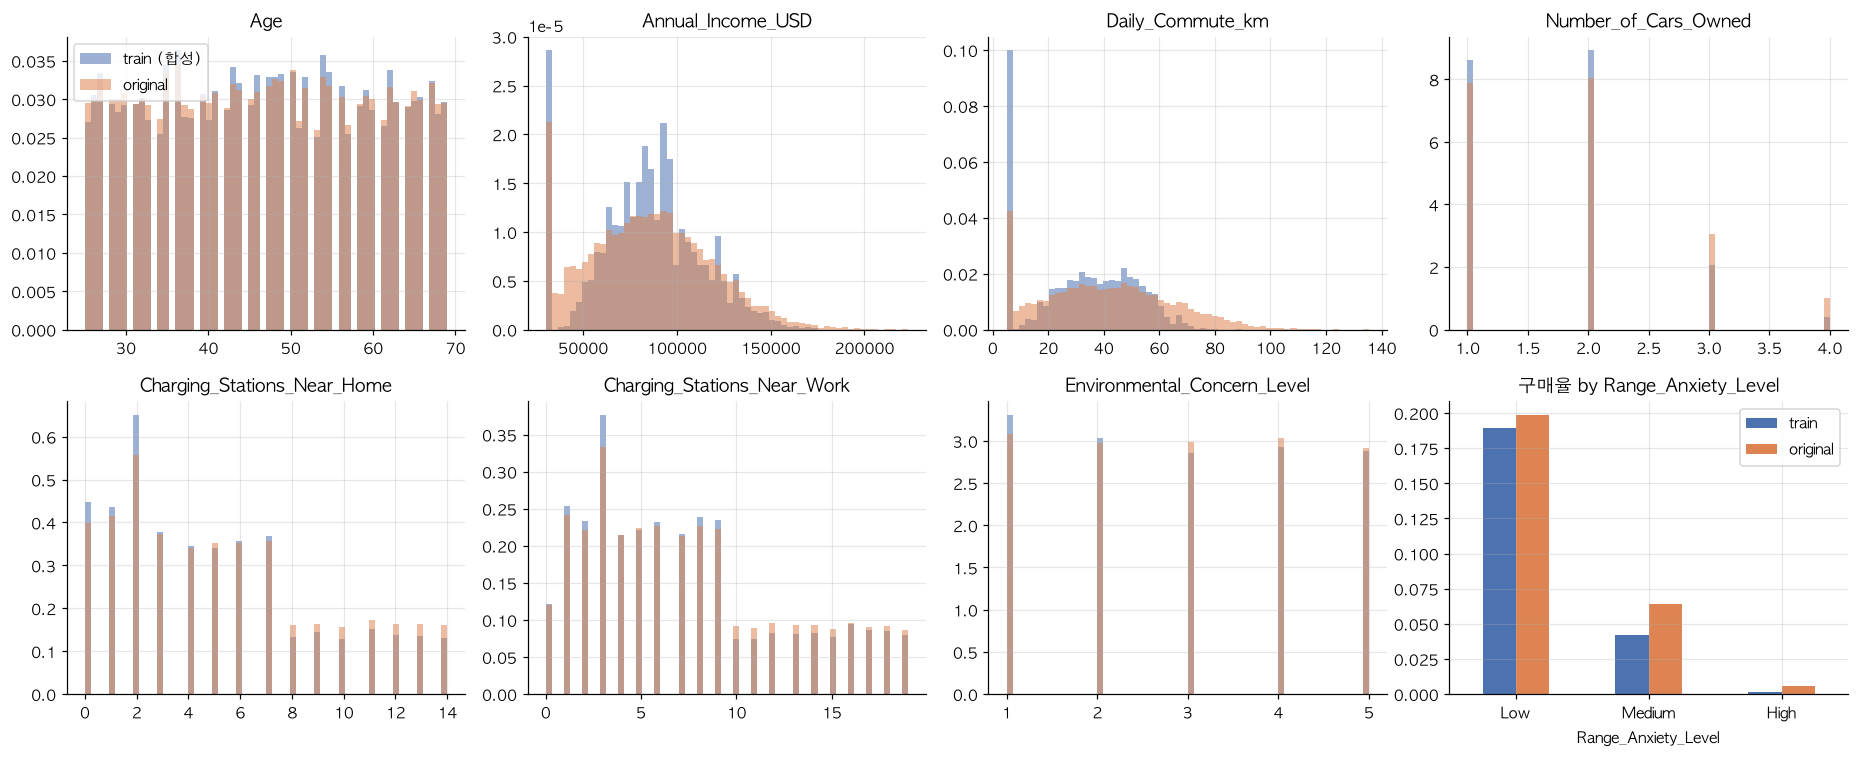

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, c in zip(axes.ravel(), NUM + ["_rate"]):
    if c == "_rate":
        r = pd.DataFrame({"train": train.groupby("Range_Anxiety_Level")[TARGET].apply(lambda s: (s == "Yes").mean()),
                          "original": orig.groupby("Range_Anxiety_Level")[TARGET].apply(lambda s: (s == "Yes").mean())})
        r.loc[["Low", "Medium", "High"]].plot.bar(ax=ax, rot=0, color=["#4C72B0", "#DD8452"])
        ax.set_title("구매율 by Range_Anxiety_Level"); continue
    bins = np.histogram_bin_edges(pd.concat([train[c], orig[c]]).dropna(), bins=60)
    ax.hist(train[c], bins=bins, density=True, alpha=.55, label="train (합성)", color="#4C72B0")
    ax.hist(orig[c].dropna(), bins=bins, density=True, alpha=.55, label="original", color="#DD8452")
    ax.set_title(c)
axes[0, 0].legend()
plt.tight_layout(); plt.show()

분포의 모양은 거의 같다. 원본에서 보이는 특징이 합성 데이터에도 그대로 남아 있다:
- **Age**는 25–69의 균등분포
- **소득**은 종 모양에 **$30,000에서 튀는 스파이크**
- **통근 거리**는 종 모양에 **5km 바닥**

### 1.3 생성기 역공학: 바닥값(floor)

In [4]:
for name, df in [("original", orig), ("train", train)]:
    inc, km = df.Annual_Income_USD.dropna(), df.Daily_Commute_km.dropna()
    print(f"{name:8s} | 소득 최솟값 {inc.min():>8,.0f}, 정확히 $30,000 비율 {(inc == 30000).mean():.2%}"
          f" | 통근 최솟값 {km.min()}, 정확히 5.0km 비율 {(km == 5.0).mean():.2%}")

original | 소득 최솟값   30,000, 정확히 $30,000 비율 5.67% | 통근 최솟값 5.0, 정확히 5.0km 비율 7.92%
train    | 소득 최솟값   30,000, 정확히 $30,000 비율 9.21% | 통근 최솟값 5.0, 정확히 5.0km 비율 21.58%


원본 생성기는 `소득 ~ N(85,000, 35,000)`을 뽑은 뒤 $30,000 미만을 $30,000으로 올리고, `통근 ~ N(40, 25)`를 뽑은 뒤 5km 미만을 5km로 올렸다 ([Chris Deotte의 EDA](https://www.kaggle.com/code/cdeotte/fable-5-1-eda-original-data-insights)). 합성 데이터도 같은 바닥값을 유지하는데, **스파이크는 더 커졌다**(소득 $30,000: 원본 5.7% → 합성 9.2%, 통근 5km: 7.9% → 21.6%). 합성기가 자주 나오는 값을 과장해서 재생산한다는 뜻이고, 이런 "정확한 값"이 모델에게 중요한 단서가 된다.

### 1.4 구매 공식 (target recipe)
Chris Deotte는 원본의 타깃이 아래 공식으로 만들어졌음을 복원했다.

$$\text{score} = 1.2\cdot\frac{\text{income}}{100{,}000} + 0.6\cdot\text{concern} + 2\cdot\text{subsidy} - 1\cdot[\text{anxiety=Medium}] - 3\cdot[\text{anxiety=High}] + \varepsilon,\quad \text{buy} \iff \text{score} > 5.5$$

공식 하나만으로 AUC가 얼마나 나오는지 확인한다.

공식 AUC | original 0.90848 | train(합성) 0.93769


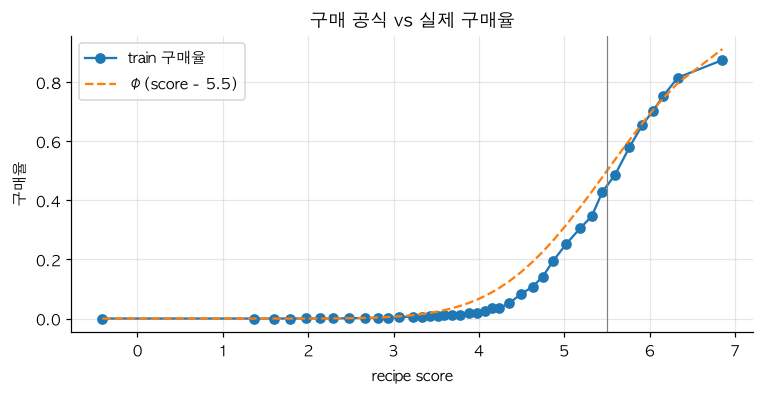

In [5]:
def recipe_score(df):
    return (1.2 * df.Annual_Income_USD / 1e5 + 0.6 * df.Environmental_Concern_Level + 2.0 * (df.Subsidy_Available == "Yes")
            - 1.0 * (df.Range_Anxiety_Level == "Medium") - 3.0 * (df.Range_Anxiety_Level == "High")).to_numpy()

o = orig.dropna(subset=["Annual_Income_USD", "Environmental_Concern_Level"])
print(f"공식 AUC | original {roc_auc_score((o[TARGET] == 'Yes'), recipe_score(o)):.5f} | train(합성) {roc_auc_score(y, recipe_score(train)):.5f}")

s = recipe_score(train); q = pd.qcut(s, 40, duplicates="drop")
rate = pd.Series(y).groupby(q, observed=True).mean(); mid = [iv.mid for iv in rate.index]
plt.figure(figsize=(8, 3.5)); plt.plot(mid, rate.values, "o-", label="train 구매율")
plt.plot(mid, norm.cdf(np.array(mid) - 5.5), "--", label="Φ(score - 5.5)")
plt.axvline(5.5, color="gray", lw=.8); plt.xlabel("recipe score"); plt.ylabel("구매율"); plt.legend(); plt.title("구매 공식 vs 실제 구매율"); plt.show()

**공식 하나로 train AUC 0.938**이다(원본 0.908보다 높다 — 합성기가 공식을 원본보다 더 결정적으로 재현했다). 리더보드 상위가 0.946 근처이므로, 모든 모델의 경쟁은 "공식이 놓친 0.008"에서 벌어진다. 합성기가 공식을 완벽히 재현하지 못해 생긴 **왜곡**을 잡는 것이 핵심이다.

### 1.5 소득 숫자의 토큰 구조
합성 데이터 생성기는 숫자를 **문자열 토큰**으로 다룬다(LLM 기반 생성기). 그래서 같은 소득 값이 여러 번 반복되고, 소득의 **앞자리 토큰**마다 구매율이 공식과 다르게 어긋난다. GPT-2 토크나이저로 소득을 쪼개 보면:

In [6]:
tok = Tokenizer.from_pretrained("gpt2")
for v in [92887, 30000, 170537, 45123]:
    print(f"{v:>7} → {tok.encode(' ' + str(v)).tokens}")

full = pd.concat([train.drop(columns=[TARGET]), test], ignore_index=True)
inc_str = full.Annual_Income_USD.astype(np.int64).astype(str)
uniq = inc_str.unique(); toks = {u: tok.encode(" " + u).ids for u in uniq}
full["L1"] = inc_str.map(lambda s: toks[s][0])
full["NTOK"] = inc_str.map(lambda s: len(toks[s]))
cnt = full.Annual_Income_USD.map(full.Annual_Income_USD.value_counts())
print(f"\n고유 소득 값 {len(uniq):,}개 / 전체 {len(full):,}행 → 값당 평균 {len(full) / len(uniq):.1f}회 반복")
print(f"train+test에서 2번 이상 나오는 소득 값의 행 비율: {(cnt >= 2).mean():.1%}")

  92887 → ['Ġ9', '28', '87']
  30000 → ['Ġ3', '0000']
 170537 → ['Ġ17', '05', '37']
  45123 → ['Ġ45', '123']



고유 소득 값 14,667개 / 전체 955,236행 → 값당 평균 65.1회 반복
train+test에서 2번 이상 나오는 소득 값의 행 비율: 99.6%


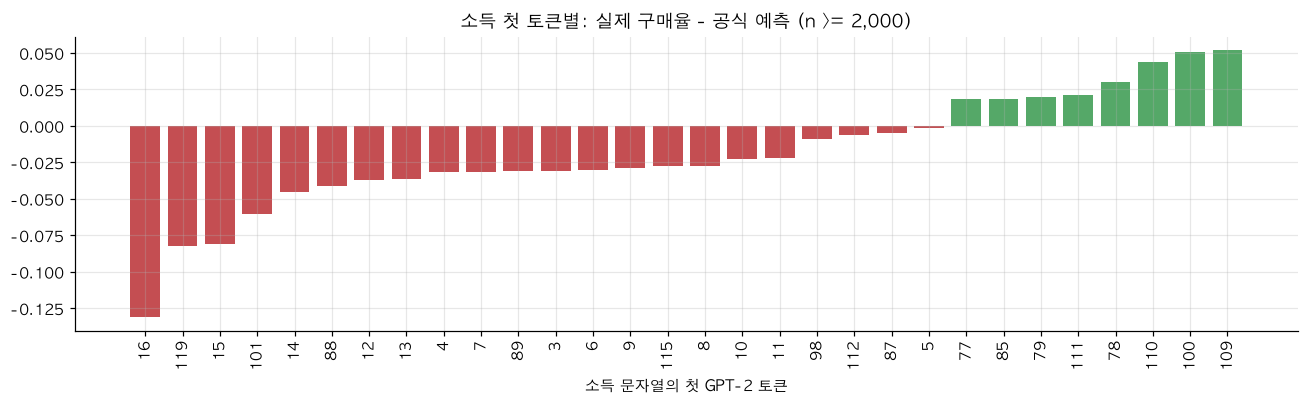

In [7]:
tr = full.iloc[:len(train)].assign(y=y, resid=y - norm.cdf(recipe_score(train) - 5.5))
g = tr.groupby("L1").agg(n=("y", "size"), 구매율=("y", "mean"), 공식대비_잔차=("resid", "mean"))
g["첫 토큰"] = [tok.id_to_token(i).replace("Ġ", "") for i in g.index]
g = g[g.n >= 2000].sort_values("공식대비_잔차")
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.bar(g["첫 토큰"].astype(str), g["공식대비_잔차"], color=np.where(g["공식대비_잔차"] > 0, "#55A868", "#C44E52"))
ax.set_title("소득 첫 토큰별: 실제 구매율 - 공식 예측 (n >= 2,000)"); ax.set_xlabel("소득 문자열의 첫 GPT-2 토큰"); ax.tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()

공식이 소득을 연속적으로 다루는데도, **첫 토큰에 따라 공식 대비 잔차가 체계적으로 달라진다.** 생성기가 토큰 단위로 값을 만들면서 생긴 왜곡이다. 이것을 특징으로 쓰는 것이 [heuljax의 Generator-Aware Ridge LR](https://www.kaggle.com/code/heuljax/kps6e09-generator-aware-ridge-logistic-regression)의 핵심 아이디어이며, 대회 후반 가장 큰 점수 상승을 만들었다.

### 1.6 Train / Test 차이 (adversarial validation)

In [8]:
adv = pd.concat([train[NUM + CAT], test[NUM + CAT]], ignore_index=True)
for c in CAT: adv[c] = adv[c].astype("category")
is_test = np.r_[np.zeros(len(train)), np.ones(len(test))]
aucs = []
for tr_i, va_i in StratifiedKFold(5, shuffle=True, random_state=0).split(adv, is_test):
    m = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, tree_method="hist", enable_categorical=True, n_jobs=-1)
    m.fit(adv.iloc[tr_i], is_test[tr_i]); aucs.append(roc_auc_score(is_test[va_i], m.predict_proba(adv.iloc[va_i])[:, 1]))
print(f"train vs test 판별 AUC = {np.mean(aucs):.4f}  (0.5면 같은 분포)")

train vs test 판별 AUC = 0.4990  (0.5면 같은 분포)


판별 AUC가 0.5 근처라 train과 test는 같은 생성기에서 나왔다. **CV를 믿어도 된다**는 뜻이고, 실제로 대회 결과에서도 Private 순위는 CV를 따라갔다(4장).

## 2. 검증 설계
모든 모델이 같은 `StratifiedKFold(5, shuffle=True, random_state=42)`로 OOF를 만든다. target encoding처럼 라벨을 쓰는 특징은 **fold 안에서만** 만든다. 학습 행은 다시 inner 5-fold로 교차 적합(cross-fit)해서 자기 라벨을 보지 않게 한다.

In [9]:
FOLDS = list(StratifiedKFold(5, shuffle=True, random_state=42).split(np.zeros(len(y)), y))
NTR = len(train)
OOF, TEST = {}, {}

def report(name):
    per = [roc_auc_score(y[v], OOF[name][v]) for _, v in FOLDS]
    print(f"{name:28s} OOF AUC {roc_auc_score(y, OOF[name]):.6f} | folds " + " ".join(f"{a:.5f}" for a in per))

## 3. 모델

### 3.A 원 특징 XGBoost (기준선)
원 특징 + 간단한 상호작용 특징(충전 걱정 점수, 보조금 상호작용).

In [10]:
def base_features(df):
    X = df[NUM + CAT].copy()
    home = (df.Home_Charging_Possible == "Yes").astype(int); sub = (df.Subsidy_Available == "Yes").astype(int)
    X["worry_score"] = df.Daily_Commute_km - 5 * df.Charging_Stations_Near_Home - 5 * df.Charging_Stations_Near_Work - 150 * home
    X["income_x_subsidy"] = df.Annual_Income_USD / 1e5 * sub
    X["concern_x_subsidy"] = df.Environmental_Concern_Level * sub
    for c in CAT: X[c] = X[c].astype("category")
    return X

XB = base_features(pd.concat([train, test], ignore_index=True))
X_tr, X_te = XB.iloc[:NTR].reset_index(drop=True), XB.iloc[NTR:].reset_index(drop=True)
XGB_PARAMS = dict(n_estimators=4000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                  tree_method="hist", enable_categorical=True, eval_metric="auc", early_stopping_rounds=200, n_jobs=-1)

def run_xgb(name, X, Xt, margin=None, margin_t=None):
    oof, pred, t0 = np.zeros(NTR), np.zeros(len(Xt)), time.time()
    for k, (t, v) in enumerate(FOLDS):
        m = xgb.XGBClassifier(**XGB_PARAMS, random_state=k)
        mt, mv, mte = (None, None, None) if margin is None else (margin[k][0], margin[k][1], margin_t[k])
        m.fit(X.iloc[t], y[t], base_margin=mt, eval_set=[(X.iloc[v], y[v])], base_margin_eval_set=None if mv is None else [mv], verbose=False)
        oof[v] = m.predict(X.iloc[v], output_margin=True, base_margin=mv)
        pred += m.predict(Xt, output_margin=True, base_margin=mte) / len(FOLDS)
    OOF[name], TEST[name] = oof, pred
    report(name); print(f"{'':28s} {time.time() - t0:.0f}s")

run_xgb("A. XGB (raw)", X_tr, X_te)

A. XGB (raw)                 OOF AUC 0.941902 | folds 0.94070 0.94176 0.94275 0.94247 0.94187
                             69s


### 3.B 구매 공식을 base margin으로
공식의 확률 `Φ(score − 5.5)`를 logit으로 바꿔 **모든 행의 출발점**으로 준다. 트리는 공식이 틀린 부분만 학습한다 ([Chris Deotte의 XGB starter](https://www.kaggle.com/code/cdeotte/fable-5-1-xgb-starter)). 공식은 각 행 자신의 특징만 쓰므로 누수가 없다.

In [11]:
def recipe_logit(df):
    p = np.clip(norm.cdf(recipe_score(df) - 5.5), 1e-6, 1 - 1e-6); return np.log(p / (1 - p))

r_tr, r_te = recipe_logit(train), recipe_logit(test)
run_xgb("B. XGB (recipe margin)", X_tr, X_te, margin=[(r_tr[t], r_tr[v]) for t, v in FOLDS], margin_t=[r_te] * len(FOLDS))

B. XGB (recipe margin)       OOF AUC 0.941937 | folds 0.94071 0.94178 0.94292 0.94247 0.94183
                             59s


### 3.C Generator-Aware Ridge LR (간소화판)
소득을 GPT-2 토큰 계층(`첫 토큰 → 앞 두 토큰 → 정확한 값`)으로 보고, 각 층의 구매율을 **부모 층 쪽으로 수축하는 beta chain**으로 추정한다. 여기에 토큰 × 맥락(보조금, 관심도, 불안 수준 등) 교차, 통근 정수값, 범주 쌍의 smoothed target rate를 더해 **ridge 로지스틱 회귀**에 넣는다. 라벨을 쓰는 모든 특징은 fold 안에서 cross-fit한다.

In [12]:
def fz(a):
    return pd.factorize(pd.Series(a), sort=False)[0].astype(np.int64)

F = pd.concat([train.drop(columns=[TARGET]), test], ignore_index=True)
ids = [toks[s] for s in inc_str]
K = {"L1": fz([t[0] for t in ids]), "L2": fz([t[0] * 60000 + (t[1] if len(t) > 1 else -1) for t in ids]),
     "IV": fz(inc_str), "LAST": fz([len(t) * 60000 + t[-1] for t in ids]),
     "CV": fz(F.Daily_Commute_km), "CI": fz(np.floor(F.Daily_Commute_km)), "AGE": fz(F.Age)}
for c in CAT + ["Environmental_Concern_Level", "Number_of_Cars_Owned"]:
    K[c] = fz(F[c])
K["CELL"] = fz(F.Subsidy_Available + F.Environmental_Concern_Level.astype(str) + F.Range_Anxiety_Level + F.Home_Charging_Possible)
cross = lambda a, b: fz(K[a] * (K[b].max() + 1) + K[b])
CTX = ["Subsidy_Available", "Environmental_Concern_Level", "Range_Anxiety_Level", "Home_Charging_Possible", "City_Type"]

FLAT = {f"r_{k}": (K[k], a) for k in ["L1", "L2", "LAST", "IV", "CV", "CI", "AGE"] for a in (5, 50)}
FLAT |= {f"tok_{l}_{c}": (cross(l, c), 20) for l in ["L1", "L2"] for c in CTX}
FLAT |= {f"ci_{c}": (cross("CI", c), 20) for c in CTX}
FLAT |= {"cell": (K["CELL"], 5), "cell_L1": (cross("CELL", "L1"), 20), "cell_CI": (cross("CELL", "CI"), 20)}
FLAT |= {f"pair_{a}_{b}": (cross(a, b), 20) for i, a in enumerate(CTX) for b in CTX[i + 1:]}
CHAIN = [K["L1"], K["L2"], K["IV"]]

# 라벨을 쓰지 않는 특징: 원 수치, one-hot, train+test 빈도, 공식 점수
LF = [F[c].to_numpy(float) for c in ["Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
                                      "Charging_Stations_Near_Home", "Charging_Stations_Near_Work", "Environmental_Concern_Level"]]
LF += [(F[c] == v).to_numpy(float) for c in CAT for v in sorted(F[c].unique())[1:]]
LF += [np.log1p(np.bincount(K[k])[K[k]]) for k in ["IV", "CV", "L2"]]
LF += [recipe_score(F), np.minimum(F.Annual_Income_USD, 200000) ** 2 / 1e10]
LF = np.column_stack(LF).astype(np.float32)
P = len(FLAT) + len(CHAIN)
print(f"label 특징 {P}개 + label-free 특징 {LF.shape[1]}개")

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))

def encode(fit, app):
    out, prior = np.empty((len(app), P), np.float32), y[fit].mean()
    for j, (key, a) in enumerate(FLAT.values()):
        s = np.bincount(key[fit], weights=y[fit], minlength=key.max() + 1); n = np.bincount(key[fit], minlength=key.max() + 1)
        out[:, j] = logit((s[key[app]] + a * prior) / (n[key[app]] + a))
    post = np.full(len(app), prior)
    for j, key in enumerate(CHAIN, start=len(FLAT)):
        s = np.bincount(key[fit], weights=y[fit], minlength=key.max() + 1); n = np.bincount(key[fit], minlength=key.max() + 1)
        post = (s[key[app]] + 20 * post) / (n[key[app]] + 20); out[:, j] = logit(post)
    return out

def fold_matrices(t, v):
    # valid/test: 바깥 학습 fold 전체로 인코딩 / 학습 행: inner 5-fold로 cross-fit
    Mt = np.empty((len(t), P), np.float32)
    for a, b in StratifiedKFold(5, shuffle=True, random_state=7).split(t, y[t]):
        Mt[b] = encode(t[a], t[b])
    te_rows = np.arange(NTR, len(F))
    return (np.hstack([Mt, LF[t]]), np.hstack([encode(t, v), LF[v]]), np.hstack([encode(t, te_rows), LF[te_rows]]))

def fit_lr(X, yy, Xs):
    mu, sd = X.mean(0), X.std(0) + 1e-6
    m = LogisticRegression(C=0.05, max_iter=3000).fit((X - mu) / sd, yy)
    return [m.decision_function((Z - mu) / sd) for Z in Xs]

oof_c, pred_c, MARG, t0 = np.zeros(NTR), np.zeros(len(test)), [], time.time()
for k, (t, v) in enumerate(FOLDS):
    Mt, Mv, Me = fold_matrices(t, v)
    ev, ee = fit_lr(Mt, y[t], [Mv, Me])
    oof_c[v] = ev; pred_c += ee / len(FOLDS)
    et = np.empty(len(t))  # D 모델용: 학습 행의 logit도 inner-CV로 (자기 라벨을 본 logit 금지)
    for a, b in StratifiedKFold(5, shuffle=True, random_state=11).split(t, y[t]):
        et[b] = fit_lr(Mt[a], y[t][a], [Mt[b]])[0]
    MARG.append((et, ev, ee, Mt, Mv, Me))
    print(f"fold {k + 1}: LR AUC {roc_auc_score(y[v], ev):.5f} | 학습 행 inner-CV logit AUC {roc_auc_score(y[t], et):.5f} | {time.time() - t0:.0f}s")
OOF["C. Generator-Aware LR"], TEST["C. Generator-Aware LR"] = oof_c, pred_c
report("C. Generator-Aware LR")

label 특징 38개 + label-free 특징 23개


fold 1: LR AUC 0.94521 | 학습 행 inner-CV logit AUC 0.94615 | 6s


fold 2: LR AUC 0.94578 | 학습 행 inner-CV logit AUC 0.94602 | 11s


fold 3: LR AUC 0.94700 | 학습 행 inner-CV logit AUC 0.94574 | 16s


fold 4: LR AUC 0.94652 | 학습 행 inner-CV logit AUC 0.94583 | 21s


fold 5: LR AUC 0.94619 | 학습 행 inner-CV logit AUC 0.94598 | 26s
C. Generator-Aware LR        OOF AUC 0.946138 | folds 0.94521 0.94578 0.94700 0.94652 0.94619


### 3.D LR logit에서 출발하는 잔차 XGBoost
C의 logit을 base margin으로 주고, 원 특징 + C에서 만든 target-rate 특징으로 XGBoost를 학습한다. 학습 행에는 **inner-CV로 만든 logit**을 줘서 자기 라벨이 출발점에 섞이지 않게 한다. 대회에서 이 방식이 heuljax XGB를 OOF 0.94617 → 0.94650으로 올렸다.

In [13]:
NAMES = list(FLAT) + ["chain_L1", "chain_L2", "chain_IV"]
oof_d, pred_d, t0 = np.zeros(NTR), np.zeros(len(test)), time.time()
for k, (t, v) in enumerate(FOLDS):
    et, ev, ee, Mt, Mv, Me = MARG[k]
    Zt, Zv, Ze = (pd.concat([X.reset_index(drop=True), pd.DataFrame(M[:, :P], columns=NAMES)], axis=1)
                  for X, M in [(X_tr.iloc[t], Mt), (X_tr.iloc[v], Mv), (X_te, Me)])
    m = xgb.XGBClassifier(**(XGB_PARAMS | dict(learning_rate=0.02, max_depth=5, colsample_bytree=0.5)), random_state=k)
    m.fit(Zt, y[t], base_margin=et, eval_set=[(Zv, y[v])], base_margin_eval_set=[ev], verbose=False)
    oof_d[v] = m.predict(Zv, output_margin=True, base_margin=ev)
    pred_d += m.predict(Ze, output_margin=True, base_margin=ee) / len(FOLDS)
    print(f"fold {k + 1}: AUC {roc_auc_score(y[v], oof_d[v]):.5f} (LR 단독 {roc_auc_score(y[v], ev):.5f}) trees={m.best_iteration} | {time.time() - t0:.0f}s")
OOF["D. LR-margin XGB"], TEST["D. LR-margin XGB"] = oof_d, pred_d
report("D. LR-margin XGB")

fold 1: AUC 0.94555 (LR 단독 0.94521) trees=671 | 21s


fold 2: AUC 0.94617 (LR 단독 0.94578) trees=804 | 46s


fold 3: AUC 0.94725 (LR 단독 0.94700) trees=541 | 63s


fold 4: AUC 0.94675 (LR 단독 0.94652) trees=429 | 79s


fold 5: AUC 0.94651 (LR 단독 0.94619) trees=482 | 96s


D. LR-margin XGB             OOF AUC 0.946439 | folds 0.94555 0.94617 0.94725 0.94675 0.94651


### 3.E L2 로지스틱 회귀 Stacker
Chris Deotte의 [GPU Logistic Regression Stacker](https://www.kaggle.com/code/cdeotte/gpu-logistic-regression-stacker)와 같은 방식이다. 각 모델 예측을 **fold 안에서** 순위 → 정규점수로 바꾸고(fold마다 보정이 달라서 생기는 왜곡 제거), 같은 5-fold 안에서 로지스틱 회귀를 학습한다. **음수 가중치도 허용**되므로 "잔차 모델 − 출발점 모델" 같은 차이 정보까지 쓴다.

In [14]:
def gauss_rank(v):
    return norm.ppf((rankdata(v) - 0.5) / len(v))

models = list(OOF)
Xo = np.column_stack([np.concatenate([gauss_rank(OOF[m][v]) for _, v in FOLDS])[np.argsort(np.concatenate([v for _, v in FOLDS]))] for m in models])
Xt = np.column_stack([gauss_rank(TEST[m]) for m in models])
oof_e, pred_e, coefs = np.zeros(NTR), np.zeros(len(test)), []
for t, v in FOLDS:
    mu, sd = Xo[t].mean(0), Xo[t].std(0)
    m = LogisticRegression(C=1.0, max_iter=2000).fit((Xo[t] - mu) / sd, y[t])
    oof_e[v] = m.decision_function((Xo[v] - mu) / sd); pred_e += m.decision_function((Xt - mu) / sd) / len(FOLDS); coefs.append(m.coef_[0])
OOF["E. L2 LR stacker"], TEST["E. L2 LR stacker"] = oof_e, pred_e
print("stacker 계수:", dict(zip(models, np.mean(coefs, 0).round(3))))
report("E. L2 LR stacker")

stacker 계수: {'A. XGB (raw)': np.float64(0.159), 'B. XGB (recipe margin)': np.float64(0.057), 'C. Generator-Aware LR': np.float64(0.717), 'D. LR-margin XGB': np.float64(2.387)}
E. L2 LR stacker             OOF AUC 0.946420 | folds 0.94553 0.94610 0.94727 0.94677 0.94645


### 3.F 모델 비교

,OOF AUC,fold 0,fold 1,fold 2,fold 3,fold 4,vs A (평균),개선 fold 수
A. XGB (raw),0.941902,0.940701,0.941756,0.942754,0.942470,0.941872,+0.000000,0
B. XGB (recipe margin),0.941937,0.940715,0.941778,0.942921,0.942475,0.941827,+0.000032,4
C. Generator-Aware LR,0.946138,0.945209,0.945779,0.947004,0.946521,0.946193,+0.004230,5
D. LR-margin XGB,0.946439,0.945547,0.946165,0.947254,0.946745,0.946511,+0.004534,5
E. L2 LR stacker,0.946420,0.945527,0.946095,0.947268,0.946766,0.946448,+0.004510,5


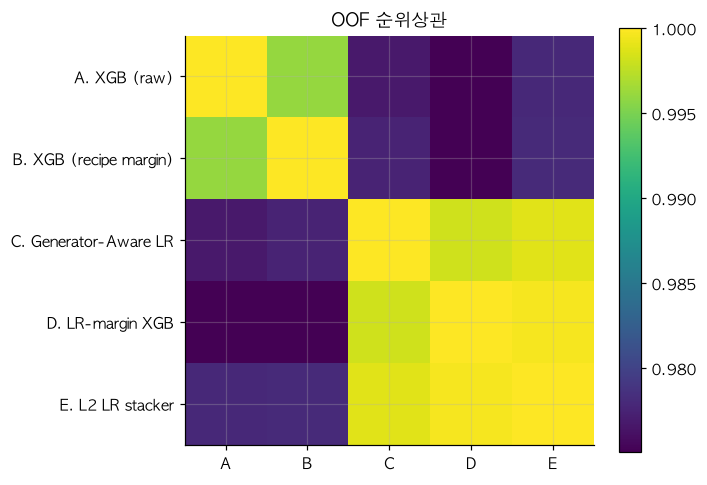

,id,Will_Buy_EV
0,668665,0.545655
1,668666,0.511493
2,668667,0.297825
3,668668,0.246333
4,668669,0.547896


In [15]:
res = pd.DataFrame({m: [roc_auc_score(y, OOF[m])] + [roc_auc_score(y[v], OOF[m][v]) for _, v in FOLDS] for m in OOF},
                   index=["OOF AUC"] + [f"fold {k}" for k in range(5)]).T
base = res.loc["A. XGB (raw)"]
res["vs A (평균)"] = (res.iloc[:, 1:6].sub(base.iloc[1:6], axis=1)).mean(1)
res["개선 fold 수"] = (res.iloc[:, 1:6].sub(base.iloc[1:6], axis=1) > 0).sum(1)
display(res.style.format({c: "{:.6f}" for c in res.columns[:6]} | {"vs A (평균)": "{:+.6f}"}).background_gradient(subset=["OOF AUC"], cmap="Greens"))

C_ = np.corrcoef([rankdata(OOF[m]) for m in OOF]); fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(C_, cmap="viridis", vmin=C_.min(), vmax=1); ax.set_xticks(range(len(OOF))); ax.set_yticks(range(len(OOF)))
ax.set_xticklabels([m.split(".")[0] for m in OOF]); ax.set_yticklabels(list(OOF)); plt.colorbar(im); ax.set_title("OOF 순위상관"); plt.show()

sub = pd.DataFrame({"id": test.id, TARGET: rankdata(TEST["E. L2 LR stacker"]) / len(test)})
sub.to_csv("submission.csv", index=False); sub.head()

**결과 해석**
- **A → B**: 공식을 출발점으로 줘도 이득은 +0.00003에 그친다. 66만 행이면 트리가 공식을 스스로 찾는다.
- **A/B → C**: 원 특징 GBDT(0.9419)보다 **토큰 계층 TE + 선형 모델(0.9461)이 훨씬 강하다.** 소득의 정확한 값과 토큰 구조에 담긴 생성기 왜곡은 원 수치로는 트리가 잡기 어렵다.
- **C → D**: C의 logit에서 출발한 XGB가 5개 fold 모두에서 C를 넘는다(+0.0003). 이 노트북의 최고 모델이다.
- **E**: 이 간소화 버전에서는 stacker가 D를 넘지 못한다(D에 가중치 2.39가 몰림). D가 이미 A–C의 정보를 거의 다 담고 있기 때문이다. 대회에서는 **출발점과 특징이 서로 다른 18개 모델**을 넣었을 때 stacker가 OOF +0.00003을 냈고 그것이 우리 Private 최고였다(4장). stacker의 이득은 **멤버의 다양성**에 달려 있다.

## 4. 실제 대회 결과: Public vs Private

아래는 대회에서 실제로 낸 제출들이다. 대회용 전체 파이프라인은 이 노트북의 간소화 모델보다 크다(heuljax GA LR 원본, 공개 OOF 기반 meta 모델 v19, goodpjw 잔차 LGBM, 자체 GA-margin XGB, 18-모델 stacker).

,제출,비고,Public,Private
0,P1: 공개 GP48 잔차 + 비중·부호 미세조정 (수십 회),nan,0.94663,0.94547
1,P1 80% + heuljax Generator-Aware LR 20%,GA LR 공개 직후,0.94675,0.94556
2,P1 65% + GA LR 35%,,0.94680,0.94560
3,위 + goodpjw 잔차 LGBM 20%,LR logit 출발 LGBM,0.94682,0.94564
4,위 + 자체 GA-margin XGB 20% ← 자동 선택된 최종,OOF 0.946173 → 0.946507,0.94683,0.94567
5,위 + 자체 GA-margin XGB 30%,,0.94683,0.94568
6,위 50% + L2 LR stacker 50%,Public에서 '실패'로 판단,0.94680,0.94569
7,위 60% + 공개 blend 무리 40%,OOF 없이 Public만 보고 혼합,0.94682,0.94565


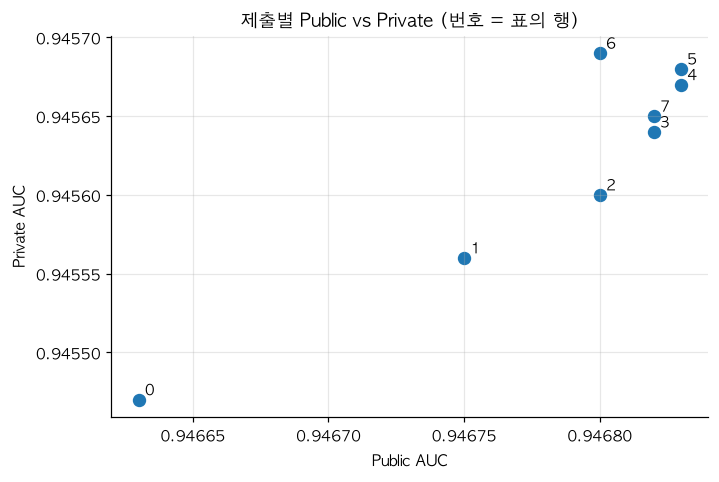

In [16]:
subs = pd.DataFrame([
    ("P1: 공개 GP48 잔차 + 비중·부호 미세조정 (수십 회)", None, 0.94663, 0.94547),
    ("P1 80% + heuljax Generator-Aware LR 20%", "GA LR 공개 직후", 0.94675, 0.94556),
    ("P1 65% + GA LR 35%", "", 0.94680, 0.94560),
    ("위 + goodpjw 잔차 LGBM 20%", "LR logit 출발 LGBM", 0.94682, 0.94564),
    ("위 + 자체 GA-margin XGB 20%  ← 자동 선택된 최종", "OOF 0.946173 → 0.946507", 0.94683, 0.94567),
    ("위 + 자체 GA-margin XGB 30%", "", 0.94683, 0.94568),
    ("위 50% + L2 LR stacker 50%", "Public에서 '실패'로 판단", 0.94680, 0.94569),
    ("위 60% + 공개 blend 무리 40%", "OOF 없이 Public만 보고 혼합", 0.94682, 0.94565),
], columns=["제출", "비고", "Public", "Private"])
display(subs.style.format({"Public": "{:.5f}", "Private": "{:.5f}"}).highlight_max(subset=["Private"], color="#c6efce"))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(subs.Public, subs.Private, s=60)
for i, r in subs.iterrows(): ax.annotate(str(i), (r.Public, r.Private), xytext=(4, 3), textcoords="offset points")
ax.xaxis.set_major_locator(plt.MaxNLocator(5)); ax.xaxis.set_major_formatter(plt.FormatStrFormatter("%.5f")); ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.5f"))
ax.set_xlabel("Public AUC"); ax.set_ylabel("Private AUC"); ax.set_title("제출별 Public vs Private (번호 = 표의 행)"); plt.show()

**읽는 법**
- Private는 **OOF로 검증한 개선이 쌓인 순서 그대로** 올랐다: GA LR → 잔차 LGBM → GA-margin XGB → stacker.
- Public에서 0.00003 낮아 "실패"로 판단한 **stacker가 Private 최고**였다. Public 소수점 다섯째 자리는 소음이었다.
- OOF 없이 Public 점수만 보고 섞은 공개 blend는 Private에서 오히려 낮았다.

| 팀 | 성격 | Public | Private |
|---|---|---:|---:|
| Chris Deotte | 자체 모델 + stacking | 3위 | **1위** (0.94602) |
| heuljax (GA LR 저자) | 자체 모델 | 6위 | 7위 |
| goodpjw2008 (잔차 GBDT 저자) | 자체 모델 | 115위 | 21위 |
| 우리 | 자체 + 공개 혼합 | 30위 | 40위 |
| 공개 제출 파일 blend 팀들 | 공개 CSV 혼합 | 33–108위 | 105–180위 |

## 5. 교훈

1. **Playground는 생성기를 역공학하는 대회다.** 구매 공식(AUC 0.94)과 소득 토큰 구조가 모든 상위 모델의 출발점이었다.
2. **강한 단순 모델의 logit을 GBDT의 출발점으로** — 같은 특징이라도 base margin으로 주면 트리가 보정에만 집중한다. 다만 같은 출발점 + 같은 특징이면 XGB/CatBoost/LGBM/MLP 모두 같은 예측으로 수렴했다(순위상관 0.9996). 다양성은 알고리즘이 아니라 **특징과 출발점**에서 나온다.
3. **고정 비중 혼합보다 L2 stacker.** 음수 가중치로 차이 정보를 쓴다. 단 입력 OOF는 반드시 end-to-end nested여야 하고, fold 안에서 순위를 매겨야 한다.
4. **Public 0.00001 단위로 판단하지 말 것.** 최종 제출 2개는 OOF 기준으로 직접 지정한다(우리는 지정하지 않아 자동 선택되었다).
5. **공개 CSV를 섞는 쪽은 Private에서 떨어지고, 자기 모델을 가진 쪽이 오른다.**

**참고한 공개 작업**: [Chris Deotte — EDA](https://www.kaggle.com/code/cdeotte/fable-5-1-eda-original-data-insights), [Chris Deotte — XGB starter](https://www.kaggle.com/code/cdeotte/fable-5-1-xgb-starter), [Chris Deotte — GPU LR stacker (S6E6)](https://www.kaggle.com/code/cdeotte/gpu-logistic-regression-stacker), [heuljax — Generator-Aware Ridge LR](https://www.kaggle.com/code/heuljax/kps6e09-generator-aware-ridge-logistic-regression), [goodpjw2008 — LR-Margin GBDT](https://www.kaggle.com/code/goodpjw2008/s6e9-lr-margin-gbdt-oof-stack-lb-0-94675)